In [22]:
import os
import numpy as np
import nibabel as nib
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid
import torchvision.transforms as transforms
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

In [13]:
BRATS_PATH = "/kaggle/input/brats2024-small-dataset/BraTS2024_small_dataset"
PMC_PATH = "/kaggle/input/pmc-tiny-dataset-t1-t2/pmc_dataset"
SAVE_PATH = "/kaggle/working/preprocessed_cgan"
os.makedirs(SAVE_PATH, exist_ok=True)

MODALITIES = {
    "t1n": "t1n.nii",
    "t1c": "t1c.nii",
    "t2w": "t2w.nii",
    "t2f": "t2f.nii"
}

IMG_SIZE = 256
SLICES_PER_PATIENT = 20


In [14]:
def preprocess_slice(img, size=IMG_SIZE):
    img = np.nan_to_num(img)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

patients = sorted(glob(os.path.join(BRATS_PATH, "*")))
print("Found", len(patients), "patients")

for patient in tqdm(patients[:50]):  # reduce if needed
    pid = os.path.basename(patient)
    volumes = {}

    for mod, suffix in MODALITIES.items():
        path = glob(os.path.join(patient, f"*{suffix}"))[0]
        volumes[mod] = nib.load(path).get_fdata()

    center = volumes["t1n"].shape[2] // 2
    z_range = range(center - SLICES_PER_PATIENT//2, center + SLICES_PER_PATIENT//2)

    for z in z_range:
        for mod in MODALITIES:
            img = preprocess_slice(volumes[mod][:, :, z])
            np.save(os.path.join(SAVE_PATH, f"{pid}_z{z}_{mod}.npy"), img)

Found 200 patients


100%|██████████| 50/50 [00:07<00:00,  6.42it/s]


In [46]:
class BraTSCGANDataset(Dataset):
    def __init__(self, path, t1_mods, t2_mods):
        self.path = path
        self.t1_mods = t1_mods
        self.t2_mods = t2_mods

        self.ids = sorted([
            f.replace(f"_{t1_mods}.npy", "")
            for f in os.listdir(path) if f.endswith(f"_{t1_mods}.npy")
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        base = self.ids[idx]
        t1_images = [np.load(os.path.join(self.path, f"{base}_{self.t1_mods}.npy"))]
        t2_images = [np.load(os.path.join(self.path, f"{base}_{self.t2_mods}.npy"))]

        t1 = torch.tensor(t1_images, dtype=torch.float32)
        t2 = torch.tensor(t2_images, dtype=torch.float32)
        return t1, t2


In [47]:
class PMCDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        self.t1_dir = os.path.join(root, 'T1')
        self.t2_dir = os.path.join(root, 'T2')
        self.t1_images = sorted(os.listdir(self.t1_dir))
        self.t2_images = sorted(os.listdir(self.t2_dir))

    def __len__(self):
        return max(len(self.t1_images), len(self.t2_images))

    def __getitem__(self, index):
        t1_path = os.path.join(self.t1_dir, self.t1_images[index])
        t2_path = os.path.join(self.t2_dir, self.t2_images[index])

        t1_images = Image.open(t1_path).convert("L")
        t2_images = Image.open(t2_path).convert("L")
        
        if self.transform:
            t1_images = self.transform(t1_images)
            t2_images = self.transform(t2_images)

        return t1_images, t2_images

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
])

Inputs: torch.Size([4, 1, 256, 256]) | Targets: torch.Size([4, 1, 256, 256])


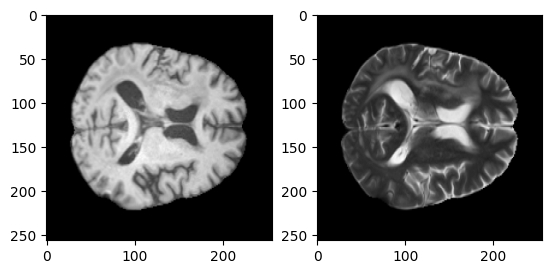

Inputs: torch.Size([4, 1, 256, 256]) | Targets: torch.Size([4, 1, 256, 256])


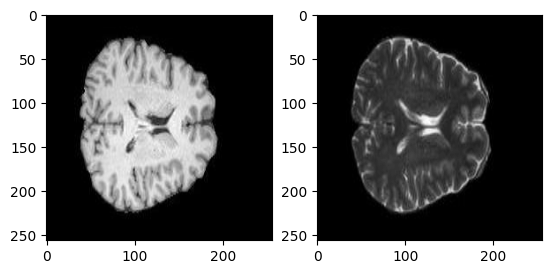

In [48]:
t1_mods = "t1n"
t2_mods = "t2w"

brats_dataset = BraTSCGANDataset(SAVE_PATH, t1_mods, t2_mods)
brats_dataloader = DataLoader(brats_dataset, batch_size=4, shuffle=True)
pmc_dataset = PMCDataset(PMC_PATH, transform)
pmc_dataloader = DataLoader(pmc_dataset, batch_size=4, shuffle=True)

t1, t2 = next(iter(brats_dataloader))
print("Inputs:", t1.shape, "| Targets:", t2.shape)
t1 = t1[0].numpy().transpose(1, 2, 0)
t2 = t2[0].numpy().transpose(1, 2, 0)
plt.subplot(1, 2, 1)
plt.imshow(t1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(t2, cmap='gray')
plt.show()

t1, t2 = next(iter(pmc_dataloader))
print("Inputs:", t1.shape, "| Targets:", t2.shape)
t1 = t1[0].numpy().transpose(1, 2, 0)
t2 = t2[0].numpy().transpose(1, 2, 0)
plt.subplot(1, 2, 1)
plt.imshow(t1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(t2, cmap='gray')
plt.show()

In [63]:
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1): # input image + cond
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, stride=2, padding=1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )

        def up_block(in_c, out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c, out_c, 4, stride=2, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.down1 = block(in_channels, 64)
        self.down2 = block(64, 128)
        self.down3 = block(128, 256)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.up3 = up_block(512, 256)
        self.up2 = up_block(256 * 2, 128)
        self.up1 = up_block(128 * 2, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(64 * 2, out_channels, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x, label):
        label = torch.ones_like(x[:, :1, :, :])*label
        d1 = self.down1(torch.cat([x, label], dim=1))
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        b = self.bottleneck(d3)
        u3 = self.up3(b)
        u2 = self.up2(torch.cat([u3, d3], dim=1))
        u1 = self.up1(torch.cat([u2, d2], dim=1))
        return self.final(torch.cat([u1, d1], dim=1))


In [64]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=3):  # input + target + cond
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 4, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x, y, label):
        label = torch.ones_like(x[:, :1, :, :])*label
        inp = torch.cat([x, y, label], dim=1)
        return self.model(inp)


In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = GeneratorUNet().to(device)
discriminator = PatchDiscriminator().to(device)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

bce = nn.BCELoss()
l1 = nn.L1Loss()
lambda_l1 = 100  # weight for L1 loss

def train_step(x, y, label):
    x, y = x.to(device), y.to(device)

    # Generate fake outputs from generator
    fake_y = generator(x, label)

    # Get discriminator output shapes
    d_real_out = discriminator(x, y, label)
    d_fake_out = discriminator(x, fake_y.detach(), label)  # detach to avoid backprop to generator

    # Dynamic label tensors based on discriminator output shape
    real_label = torch.ones_like(d_real_out, device=device)
    fake_label = torch.zeros_like(d_fake_out, device=device)

    # Discriminator loss
    d_loss_real = bce(d_real_out, real_label)
    d_loss_fake = bce(d_fake_out, fake_label)
    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    discriminator.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Generator loss
    fake_y = generator(x, label)  # forward again for gradients
    d_fake_for_g = discriminator(x, fake_y, label)
    adv_loss = bce(d_fake_for_g, real_label)  # try to fool discriminator
    l1_loss_val = l1(fake_y, y)
    g_loss = adv_loss + lambda_l1 * l1_loss_val

    generator.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    return d_loss.item(), g_loss.item(), l1_loss_val.item()


In [70]:
EPOCHS = 50
losses_g, losses_d, l1s = [], [], []

for epoch in range(1, EPOCHS + 1):
    g_epoch_loss, d_epoch_loss, l1_epoch = 0, 0, 0
    for i, dataloader in enumerate([pmc_dataloader, brats_dataloader]):
        for t1, t2 in tqdm(dataloader, desc=f"{'(Tumor)' if i == 1 else '(Non-Tumor)'} Epoch {epoch}/{EPOCHS}"):
            d_loss, g_loss, l1_loss_val = train_step(t1, t2, i) # train for t1 to t2 translation
            d_epoch_loss += d_loss
            g_epoch_loss += g_loss
            l1_epoch += l1_loss_val

    print(f"Epoch {epoch} | D: {d_epoch_loss:.4f} | G: {g_epoch_loss:.4f} | L1: {l1_epoch:.4f}")
    losses_d.append(d_epoch_loss)
    losses_g.append(g_epoch_loss)
    l1s.append(l1_epoch)


(Tumour) Epoch 1/50: 100%|██████████| 250/250 [00:37<00:00,  6.67it/s]


Epoch 1 | D: 284.7786 | G: 1520.9390 | L1: 12.2729


(Tumour) Epoch 2/50: 100%|██████████| 250/250 [00:37<00:00,  6.70it/s]


Epoch 2 | D: 283.4638 | G: 1447.6021 | L1: 11.5082


(Tumour) Epoch 3/50: 100%|██████████| 250/250 [00:37<00:00,  6.71it/s]


...

Epoch 48 | D: 283.8373 | G: 804.7124 | L1: 5.0788


(Tumour) Epoch 49/50: 100%|██████████| 250/250 [00:37<00:00,  6.71it/s]


Epoch 49 | D: 284.2032 | G: 791.1529 | L1: 4.9517


(Tumour) Epoch 50/50: 100%|██████████| 250/250 [00:37<00:00,  6.68it/s]

Epoch 50 | D: 284.0629 | G: 786.8386 | L1: 4.9055


In [71]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

def evaluate(generator, dataloader, label):
    generator.eval()
    ssim_total, psnr_total = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            preds = generator(x, label).cpu().numpy()
            targets = y.numpy()

            preds = np.clip(preds, 0, 1)
            targets = np.clip(targets, 0, 1)

            for i in range(preds.shape[0]):
                psnr_total.append(peak_signal_noise_ratio(targets[i][0], preds[i][0], data_range=1.0))
                ssim_total.append(structural_similarity(targets[i][0], preds[i][0], data_range=1.0))

    return np.mean(ssim_total), np.mean(psnr_total)

# Run this after training
ssim_val, psnr_val = evaluate(generator, pmc_dataloader, 0)
print(f"✅ SSIM (T1n -> T2w (Non-Tumor)): {ssim_val:.4f}")
print(f"✅ PSNR (T1n -> T2w (Non-Tumor)): {psnr_val:.4f}")
ssim_val, psnr_val = evaluate(generator, brats_dataloader, 1)
print(f"✅ SSIM (T1n -> T2w (Tumor)): {ssim_val:.4f}")
print(f"✅ PSNR (T1n -> T2w (Tumor)): {psnr_val:.4f}")

✅ SSIM (T1n -> T2w (Non-Tumor)): 0.4229
✅ PSNR (T1n -> T2w (Non-Tumor)): 13.0307
✅ SSIM (T2w -> T1n (Tumor)): 0.9566
✅ PSNR (T2w -> T1n (Tumor)): 33.6322


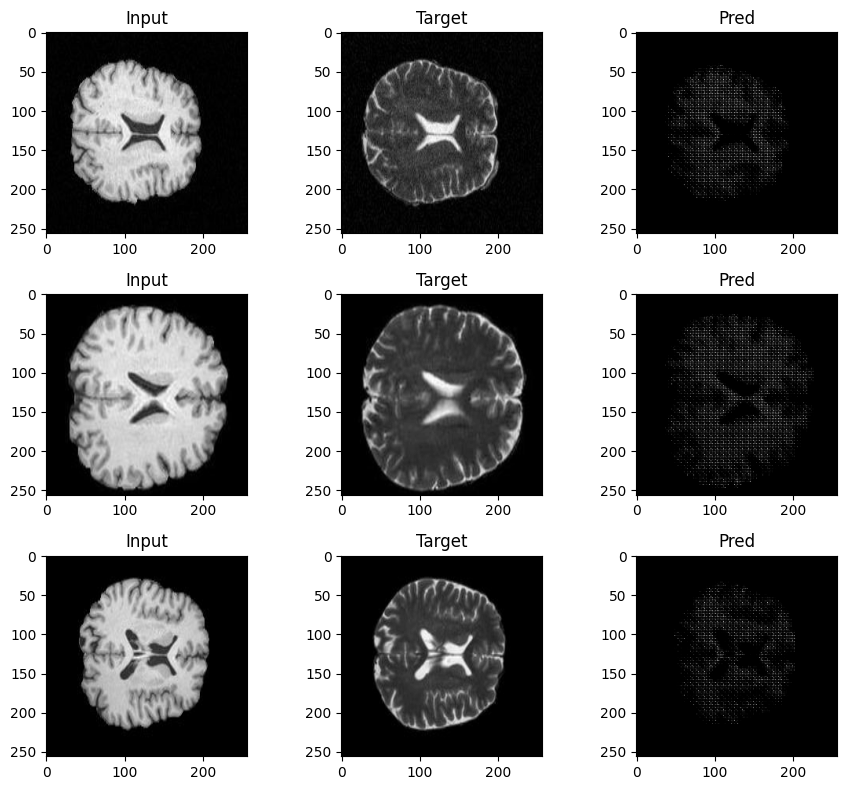

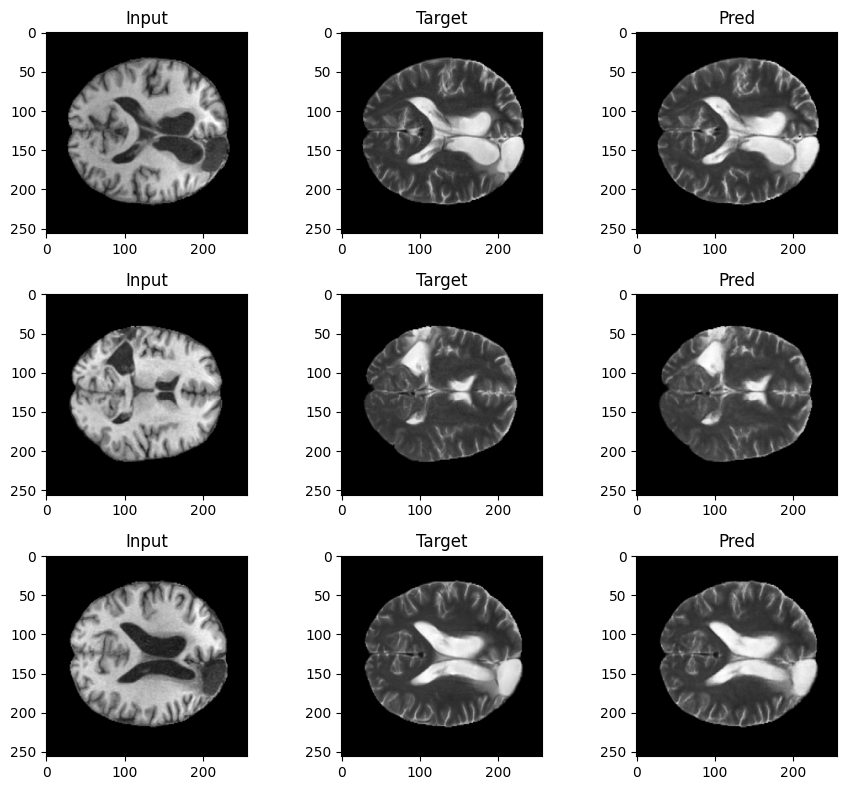

In [72]:
def visualize_samples(generator, dataloader, label):
    generator.eval()
    x, y = next(iter(dataloader))
    x = x.to(device)
    with torch.no_grad():
        preds = generator(x, label).cpu().numpy()
    x = x.cpu().numpy()
    y = y.cpu().numpy()

    plt.figure(figsize=(15, 8))
    for i in range(3):
        plt.subplot(3, 5, i*5 + 1)
        plt.imshow(x[i][0], cmap="gray")
        plt.title("Input")

        plt.subplot(3, 5, i*5 + 2)
        plt.imshow(y[i][0], cmap="gray")
        plt.title("Target")

        plt.subplot(3, 5, i*5 + 3)
        plt.imshow(preds[i][0], cmap="gray")
        plt.title("Pred")

    plt.tight_layout()
    plt.show()

visualize_samples(generator, pmc_dataloader, 0)
visualize_samples(generator, brats_dataloader, 1)


In [73]:
class Generator(nn.Module):
    """
    A U-Net style generator with 8 down-samplings and 8 up-samplings.
    This version produces the SAME spatial size as the input (means input and output remain as 256x256) 
    The final layer of the generator does not make the image bigger anymore.
    """
    def __init__(self, input_channels=1, output_channels=1):
        super(Generator, self).__init__()

        # Encoder layers
        self.e1 = self._conv_block(input_channels, 64, batch_norm=False)  # 256 -> 128
        self.e2 = self._conv_block(64, 128)                               # 128 -> 64
        self.e3 = self._conv_block(128, 256)                              # 64 -> 32
        self.e4 = self._conv_block(256, 512)                              # 32 -> 16
        self.e5 = self._conv_block(512, 512)                              # 16 -> 8
        self.e6 = self._conv_block(512, 512)                              # 8 -> 4
        self.e7 = self._conv_block(512, 512)                              # 4 -> 2
        # No batch norm on last encoder
        self.e8 = self._conv_block(512, 512, batch_norm=False)            # 2 -> 1

        # Decoder layers 
        # Each deconv_block uses stride=2 => doubles spatial dimension
        self.d1 = self._deconv_block(512, 512, dropout=True)              # 1 -> 2
        self.d2 = self._deconv_block(512 + 512, 512, dropout=True)        # 2 -> 4
        self.d3 = self._deconv_block(512 + 512, 512, dropout=True)        # 4 -> 8
        self.d4 = self._deconv_block(512 + 512, 512)                      # 8 -> 16
        self.d5 = self._deconv_block(512 + 512, 512)                      # 16 -> 32
        self.d6 = self._deconv_block(512 + 256, 256)                      # 32 -> 64
        self.d7 = self._deconv_block(256 + 128, 128)                      # 64 -> 128
        self.d8 = self._deconv_block(128 + 64, 64)                        # 128 -> 256

        # Output
        # A 3×3 conv that preserves 256×256 (stride=1),
        # mapping from 64 channels -> output_channels
        self.output = nn.Sequential(
            nn.Conv2d(64, output_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

        # Weight initialisation
        init_weights(self, init_type='normal', gain=0.02)

    # changed conv block to use InstanceNorm2d instead of BatchNorm2d
    # https://www.jmis.org/archive/view_article?pid=jmis-11-2-157
    # The last sentence in this abstract said to replace it and it procudes better results
    # (I didn't read through the whole paper after that)
    def _conv_block(self, in_channels, out_channels,
                    kernel_size=4, stride=2, padding=1, batch_norm=True):
        """
        Downsampling block: Conv2d + (Optionally) InstanceNorm + LeakyReLU.
        """
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size, stride, padding,
                                bias=not batch_norm))
        if batch_norm:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    # same thing, using InstanceNorm2d
    def _deconv_block(self, in_channels, out_channels,
                      kernel_size=4, stride=2, padding=1, dropout=False):
        """
        Upsampling block: ConvTranspose2d + InstanceNorm + ReLU (+ optional Dropout).
        """
        layers = []
        layers.append(nn.ConvTranspose2d(in_channels, out_channels,
                                         kernel_size, stride, padding,
                                         bias=False))
        layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.ReLU(True))
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        e8 = self.e8(e7)

        d1 = self.d1(e8)
        d2 = self.d2(torch.cat([d1, e7], 1))
        d3 = self.d3(torch.cat([d2, e6], 1))
        d4 = self.d4(torch.cat([d3, e5], 1))
        d5 = self.d5(torch.cat([d4, e4], 1))
        d6 = self.d6(torch.cat([d5, e3], 1))
        d7 = self.d7(torch.cat([d6, e2], 1))
        d8 = self.d8(torch.cat([d7, e1], 1))

        return self.output(d8)


In [75]:
class Discriminator(nn.Module):
    """
    Uses BCEWithLogitsLoss (so no Sigmoid at the end).
    """
    def __init__(self, in_channels=1, out_channels=1):
        super(Discriminator, self).__init__()
        
        # input is concatenation of real+condition or fake+condition => 2 channels
        self.model = nn.Sequential(
            # No normalisation in first layer
            self.disc_block(in_channels * 2, 64, batch_norm=False),
            self.disc_block(64, 128),
            self.disc_block(128, 256),
            # stride=1 for final block
            self.disc_block(256, 512, stride=1),
            nn.Conv2d(512, out_channels, kernel_size=4, stride=1, padding=1)
        )

        # Weight initialisation
        init_weights(self, init_type='normal', gain=0.02)
    
    def disc_block(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1, batch_norm=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=not batch_norm)]
        if batch_norm:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    #  The forward method is defined to take an input x
    def forward(self, x, y):
        # x: condition (T1), y: either T2 real or T2 fake
        # Concatenation along channel dim
        inp = torch.cat([x, y], dim=1)
        return self.model(inp)
        

In [25]:
torch.save(generator.state_dict(), "t1_t2_generator.pth")
torch.save(discriminator.state_dict(), "t1_t2_discriminator.pth")